## Objetivo

El objetivo principal es explorar la estructura de los datos y responder preguntas clave sobre el perfil de los clientes, así como analizar cómo se diferencian los segmentos existentes. 

En particular, se busca evaluar si es posible identificar grupos de clientes según su comportamiento de consumo y qué características influyen en dicha segmentación.

## Preguntas

Para el modelo:
* ¿Es posible identificar grupos diferenciados de clientes en función de su perfil y comportamiento de consumo?

De guia:
* ¿Cómo se distribuyen los clientes por edad?
* ¿Cuál es la proporción de género?
* ¿Qué profesiones predominan?
* ¿Cual es la distibución de edad por segmento? 
* ¿Qué segmentos tienen mayor Spending Score (Puntuación de gasto)?
* ¿Cómo se distribuyen las profesiones dentro de cada segmento de clientes?
* ¿Cómo varía la segmentación de clientes en función del nivel educativo?

## Repositorio

Link: https://github.com/mnahuelanca/segmentacion-clientes

## Librerias y config.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
#import plotly.express 

print("Librerias importadas correctamente")

Librerias importadas correctamente


In [2]:

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

## Importar datos

Link: https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation

In [3]:
df = pd.read_csv("./datos/train.csv")
print("Datos cargados correctamente")

Datos cargados correctamente


## EDA y ETL

info, describe, unicos, nulos, duplicados, categoricos, numericos,
eliminar, exportar csv final

In [4]:
df.head(5)

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


* ID = Identificador
* Gender = Genero del cliente 
* Ever_Married = Estado civil del cliente
* Age = Edad del cliente 
* Graduated = ¿El cliente es graduado?
* Prefession = Profesión del cliente 
* Work_Experience = Experiencia laboral en años
* Spending_Score = Puntuación de gasto
* Family_Size = Tamaño familiar (integrantes)
* Var_1 = Categoría anonimizada para el cliente
* Segmentation = Segmento del cliente

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


* 8068 filas,
* 11 columnas,
* 3 tipos de datos. Float, Int y Object,
* Hay valores nulos o faltantes
* Hay 1 variables anonimizada (var_1)

In [6]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,7239.000000,7733.000000
mean,463479.214551,43.466906,2.641663,2.850123
std,2595.381232,16.711696,3.406763,1.531413
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [7]:
duplicados = df.duplicated().sum()
print(f"Total de filas duplicadas: {duplicados}")

Total de filas duplicadas: 0


In [8]:
nulos = df.isnull().sum()
print(f"Total de filas nulas: \n{nulos}")

Total de filas nulas: 
ID                   0
Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64


In [9]:
# Identificar tipos de valores en cada categoría que tenga valores nulos
columns_with_nulls = ['Ever_Married', 'Graduated', 'Profession', 'Work_Experience', 'Family_Size', 'Var_1']
for col in columns_with_nulls:
    print(f"Valores únicos en {col}: {df[col].unique()}")

Valores únicos en Ever_Married: ['No' 'Yes' nan]
Valores únicos en Graduated: ['No' 'Yes' nan]
Valores únicos en Profession: ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing' nan]
Valores únicos en Work_Experience: [ 1. nan  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
Valores únicos en Family_Size: [ 4.  3.  1.  2.  6. nan  5.  8.  7.  9.]
Valores únicos en Var_1: ['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' nan 'Cat_5']


In [10]:
# Analizar y tratar valores nulos
# Para columnas categóricas (object), rellenar con la moda o 'Unknown'
# Para columnas numéricas (float/int), rellenar con la mediana (no con 0, ya que podría sesgar datos)

for col in columns_with_nulls:
    if df[col].dtype == 'object':
        mode_val = df[col].mode()[0] if not df[col].mode().empty else 'Unknown'
        df[col].fillna(mode_val, inplace=True)
        print(f"Columna {col} (categórica): rellenada con moda '{mode_val}'")
    else:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Columna {col} (numérica): rellenada con mediana {median_val}")

# Verificar que no queden nulos
print("Nulos después del tratamiento:")
print(df.isnull().sum())

Columna Ever_Married (categórica): rellenada con moda 'Yes'
Columna Graduated (categórica): rellenada con moda 'Yes'
Columna Profession (categórica): rellenada con moda 'Artist'
Columna Work_Experience (numérica): rellenada con mediana 1.0
Columna Family_Size (numérica): rellenada con mediana 3.0
Columna Var_1 (categórica): rellenada con moda 'Cat_6'
Nulos después del tratamiento:
ID                 0
Gender             0
Ever_Married       0
Age                0
Graduated          0
Profession         0
Work_Experience    0
Spending_Score     0
Family_Size        0
Var_1              0
Segmentation       0
dtype: int64


C:\Users\Usuario\AppData\Local\Temp\ipykernel_4796\3571999179.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_4796\3571999179.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, w

In [11]:
df.describe()

,ID,Age,Work_Experience,Family_Size
count,8068.000000,8068.000000,8068.000000,8068.000000
mean,463479.214551,43.466906,2.472980,2.856346
std,2595.381232,16.711696,3.265248,1.499577
min,458982.000000,18.000000,0.000000,1.000000
25%,461240.750000,30.000000,0.000000,2.000000
50%,463472.500000,40.000000,1.000000,3.000000
75%,465744.250000,53.000000,4.000000,4.000000
max,467974.000000,89.000000,14.000000,9.000000


In [12]:
# Identificar valores únicos en cada columna
for col in df.columns:
    unique_vals = df[col].unique()
    print(f"Valores únicos en {col}: {unique_vals}")

Valores únicos en ID: [462809 462643 466315 ... 465406 467299 461879]
Valores únicos en Gender: ['Male' 'Female']
Valores únicos en Ever_Married: ['No' 'Yes']
Valores únicos en Age: [22 38 67 40 56 32 33 61 55 26 19 70 58 41 31 79 49 18 36 35 45 42 83 27
 28 47 29 57 76 25 72 48 74 59 39 51 30 63 52 60 68 86 50 43 80 37 46 69
 78 71 82 23 20 85 21 53 62 75 65 89 66 73 77 87 84 81 88]
Valores únicos en Graduated: ['No' 'Yes']
Valores únicos en Profession: ['Healthcare' 'Engineer' 'Lawyer' 'Entertainment' 'Artist' 'Executive'
 'Doctor' 'Homemaker' 'Marketing']
Valores únicos en Work_Experience: [ 1.  0.  4.  9. 12.  3. 13.  5.  8. 14.  7.  2.  6. 10. 11.]
Valores únicos en Spending_Score: ['Low' 'Average' 'High']
Valores únicos en Family_Size: [4. 3. 1. 2. 6. 5. 8. 7. 9.]
Valores únicos en Var_1: ['Cat_4' 'Cat_6' 'Cat_7' 'Cat_3' 'Cat_1' 'Cat_2' 'Cat_5']
Valores únicos en Segmentation: ['D' 'A' 'B' 'C']


In [13]:
for col in df.columns:
    if col == 'ID':
        continue
    print(f"\nConteo de valores únicos en {col}:")
    if col in ['Age', 'Work_Experience', 'Family_Size']:
        if col == 'Age':
            bins = [1, 25, 35, 45, 55, 65, 100]
        elif col == 'Work_Experience':
            bins = [0, 2, 5, 10, 15]
        elif col == 'Family_Size':
            bins = [1, 2, 4, 6, 10]
        counts = df[col].value_counts(bins=bins, sort=False)
        print(counts)
    else:
        counts = df[col].value_counts()
        print(counts)


Conteo de valores únicos en Gender:
Gender
Male      4417
Female    3651
Name: count, dtype: int64

Conteo de valores únicos en Ever_Married:
Ever_Married
Yes    4783
No     3285
Name: count, dtype: int64

Conteo de valores únicos en Age:
(0.999, 25.0]     998
(25.0, 35.0]     1945
(35.0, 45.0]     1923
(45.0, 55.0]     1390
(55.0, 65.0]      805
(65.0, 100.0]    1007
Name: count, dtype: int64

Conteo de valores únicos en Graduated:
Graduated
Yes    5046
No     3022
Name: count, dtype: int64

Conteo de valores únicos en Profession:
Profession
Artist           2640
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64

Conteo de valores únicos en Work_Experience:
(-0.001, 2.0]    5787
(2.0, 5.0]        702
(5.0, 10.0]      1390
(10.0, 15.0]      189
Name: count, dtype: int64

Conteo de valores únicos en Spending_Score:
Spending_Score
Low   

In [14]:
df.rename(columns={
    'ID': 'Identificador',
    'Gender': 'Genero',
    'Ever_Married': 'Estado_Civil',
    'Age': 'Edad',
    'Graduated': 'Graduado',
    'Profession': 'Profesion',
    'Work_Experience': 'Experiencia_Laboral',
    'Spending_Score': 'Puntuacion_Gasto',
    'Family_Size': 'Tamano_Familiar',
    'Var_1': 'Categoria_Anonimizada',
    'Segmentation': 'Segmento'
}, inplace = True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Identificador          8068 non-null   int64  
 1   Genero                 8068 non-null   object 
 2   Estado_Civil           8068 non-null   object 
 3   Edad                   8068 non-null   int64  
 4   Graduado               8068 non-null   object 
 5   Profesion              8068 non-null   object 
 6   Experiencia_Laboral    8068 non-null   float64
 7   Puntuacion_Gasto       8068 non-null   object 
 8   Tamano_Familiar        8068 non-null   float64
 9   Categoria_Anonimizada  8068 non-null   object 
 10  Segmento               8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [15]:
df.drop('Categoria_Anonimizada', axis=1, inplace=True)
print("Columna 'Categoria_Anonimizada' eliminada del DataFrame.")

Columna 'Categoria_Anonimizada' eliminada del DataFrame.


In [16]:
df.head()

,Identificador,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A


In [17]:
df.describe(include='object')

,Genero,Estado_Civil,Graduado,Profesion,Puntuacion_Gasto,Segmento
count,8068,8068,8068,8068,8068,8068
unique,2,2,2,9,3,4
top,Male,Yes,Yes,Artist,Low,D
freq,4417,4783,5046,2640,4878,2268


## Exportar DF

In [18]:
df.to_csv('dfSegmentado.csv', index=False)
print("DataFrame guardado como 'dfSegmentado.csv'")

DataFrame guardado como 'dfSegmentado.csv'


In [19]:
dfFinal = pd.read_csv('dfSegmentado.csv')
dfFinal.head()

,Identificador,Genero,Estado_Civil,Edad,Graduado,Profesion,Experiencia_Laboral,Puntuacion_Gasto,Tamano_Familiar,Segmento
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,A


## Graficos

### Comparacion de Genero. ¿Cuál es la proporción de género?

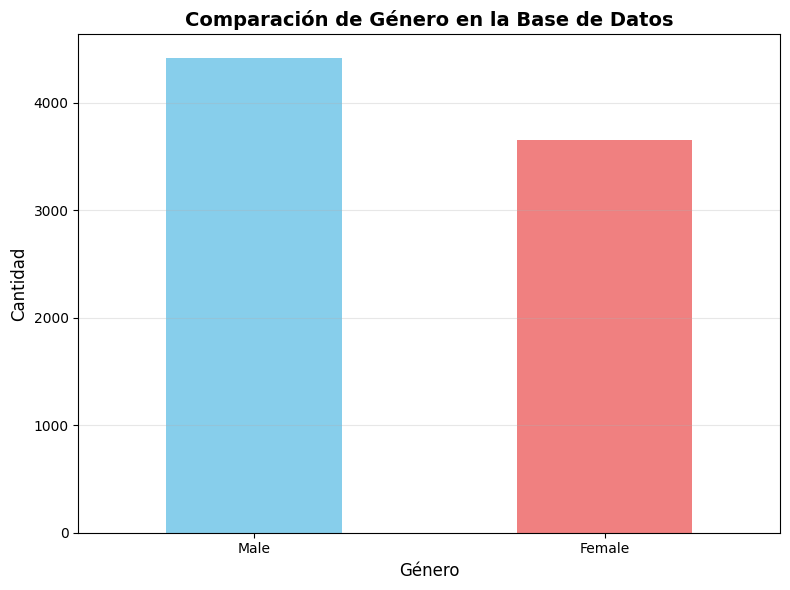

In [20]:
gender_counts = dfFinal['Genero'].value_counts()
plt.figure(figsize=(8, 6))
gender_counts.plot(kind='bar', color=['skyblue', 'lightcoral'])
plt.title('Comparación de Género en la Base de Datos', fontsize=14, fontweight='bold')
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

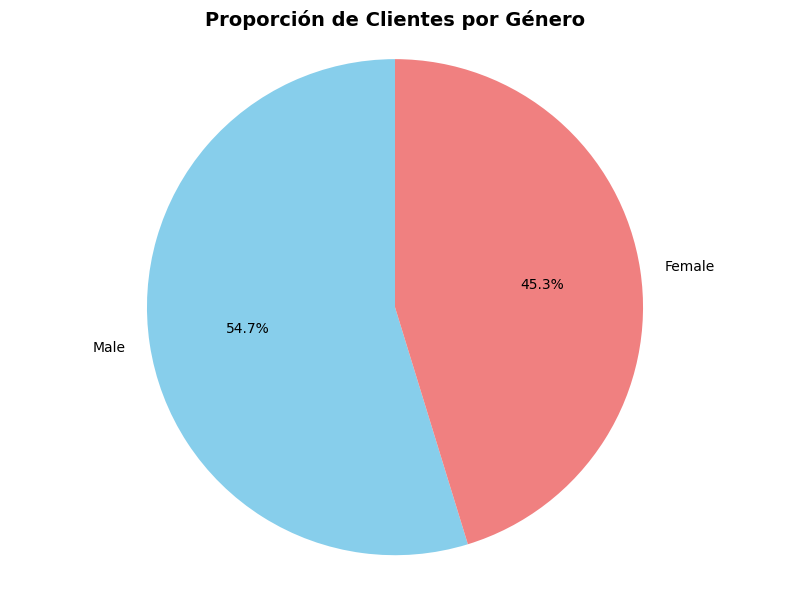

In [21]:
plt.figure(figsize=(8, 6))
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['skyblue', 'lightcoral'], startangle=90)
plt.title('Proporción de Clientes por Género', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

### Comparacion de estado civil

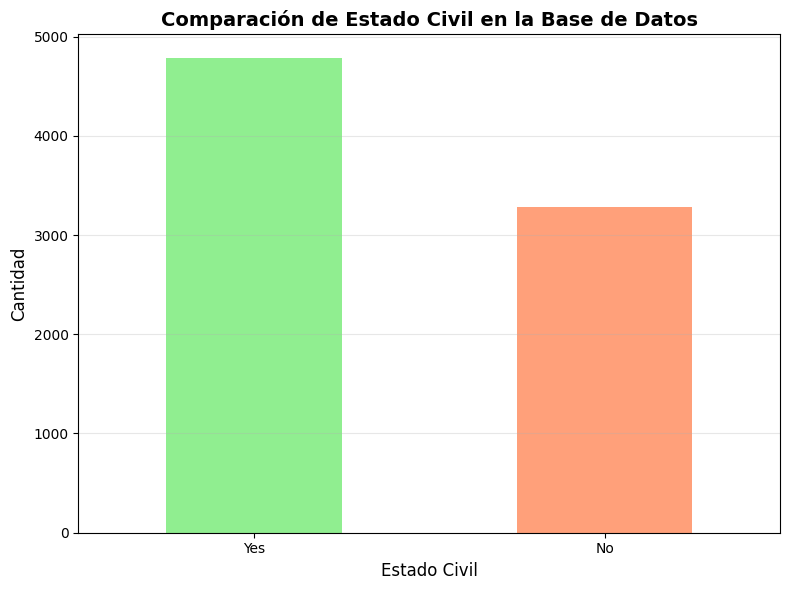

In [22]:
marital_counts = dfFinal['Estado_Civil'].value_counts()
plt.figure(figsize=(8, 6))
marital_counts.plot(kind='bar', color=['lightgreen', 'lightsalmon'])
plt.title('Comparación de Estado Civil en la Base de Datos', fontsize=14, fontweight='bold')
plt.xlabel('Estado Civil', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### ¿Cómo se distribuyen los clientes por edad?

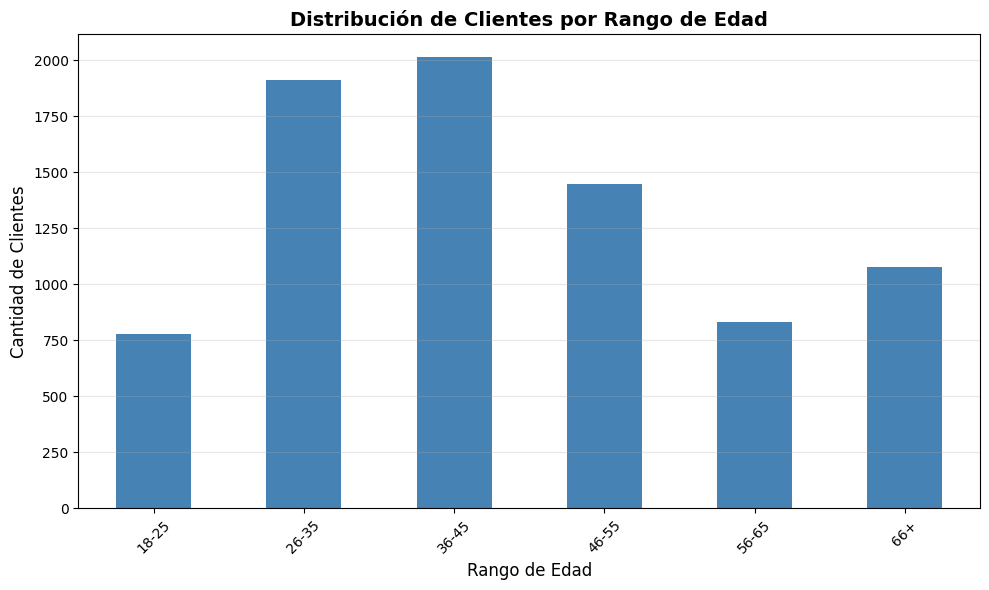

In [23]:
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66+']
dfFinal['Rango_Edad'] = pd.cut(dfFinal['Edad'], bins=age_bins, labels=age_labels, right=False)

age_range_counts = dfFinal['Rango_Edad'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
age_range_counts.plot(kind='bar', color='steelblue')
plt.title('Distribución de Clientes por Rango de Edad', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Edad', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Comparacion de clientes Graduados vs No Graduados

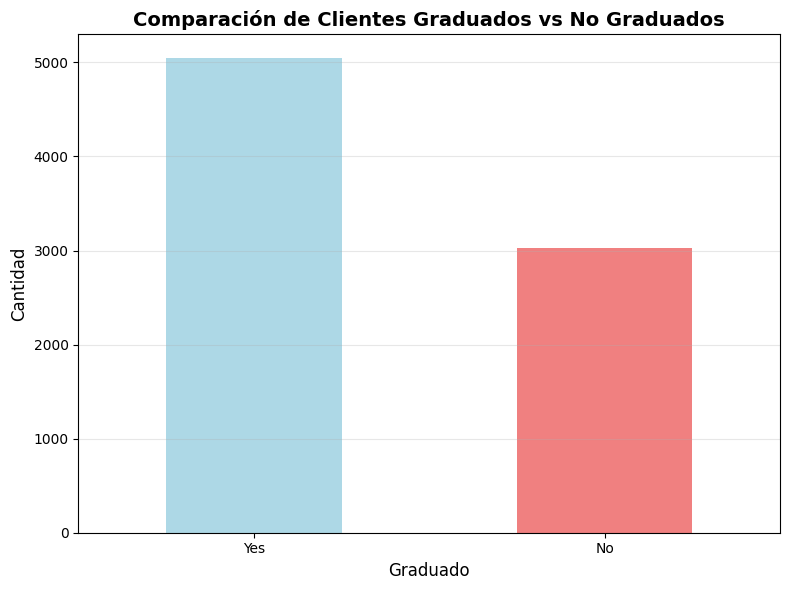

In [24]:
graduated_counts = dfFinal['Graduado'].value_counts()
plt.figure(figsize=(8, 6))
graduated_counts.plot(kind='bar', color=['lightblue', 'lightcoral'])
plt.title('Comparación de Clientes Graduados vs No Graduados', fontsize=14, fontweight='bold')
plt.xlabel('Graduado', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Cantidad de clientes por profesion. ¿Qué profesiones predominan?

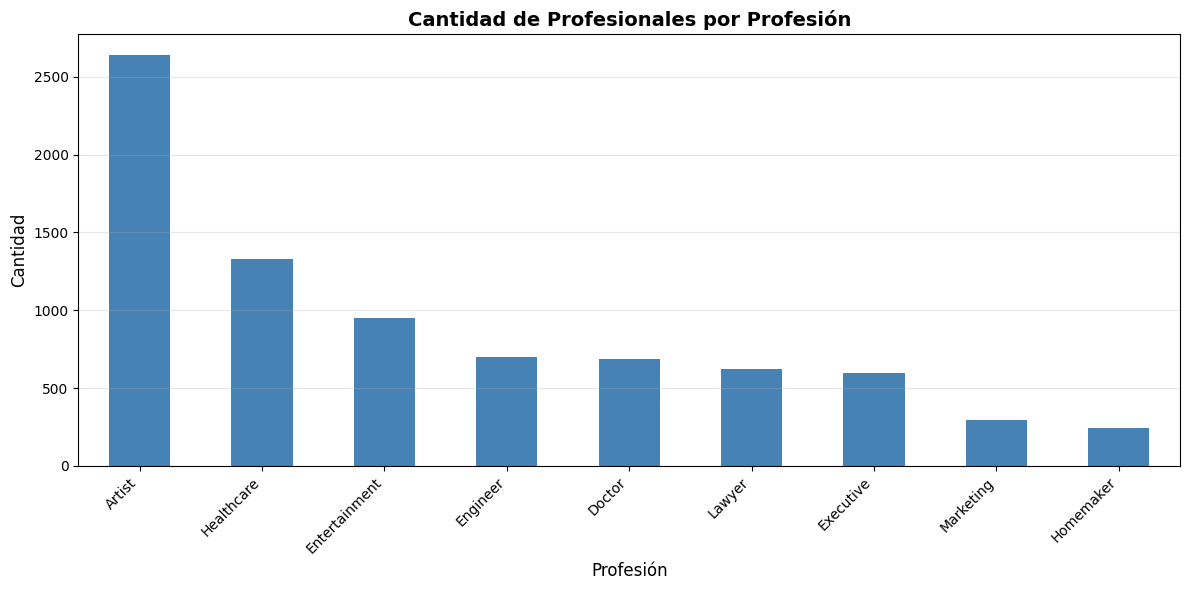

In [25]:
profession_counts = dfFinal['Profesion'].value_counts()
plt.figure(figsize=(12, 6))
profession_counts.plot(kind='bar', color='steelblue')
plt.title('Cantidad de Profesionales por Profesión', fontsize=14, fontweight='bold')
plt.xlabel('Profesión', fontsize=12)
plt.ylabel('Cantidad', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Distribución de Clientes por Rango de Experiencia Laboral

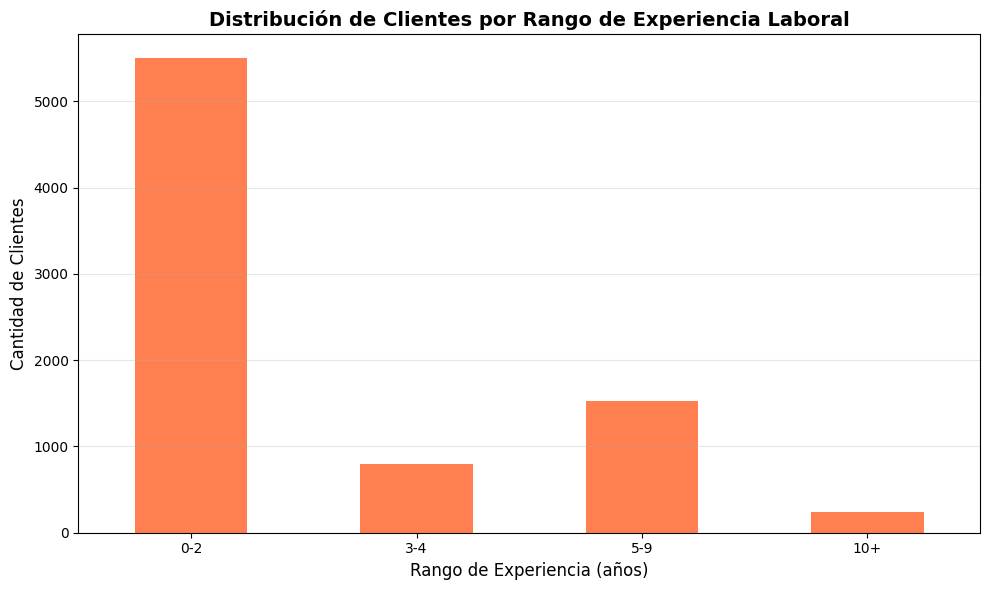

In [26]:
experience_bins = [0, 2, 5, 10, 15]
experience_labels = ['0-2', '3-4', '5-9', '10+']
dfFinal['Rango_Experiencia'] = pd.cut(dfFinal['Experiencia_Laboral'], bins=experience_bins, labels=experience_labels, right=False)

experience_range_counts = dfFinal['Rango_Experiencia'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
experience_range_counts.plot(kind='bar', color='coral')
plt.title('Distribución de Clientes por Rango de Experiencia Laboral', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Experiencia (años)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Distribución de Clientes por Rango de Tamaño Familiar

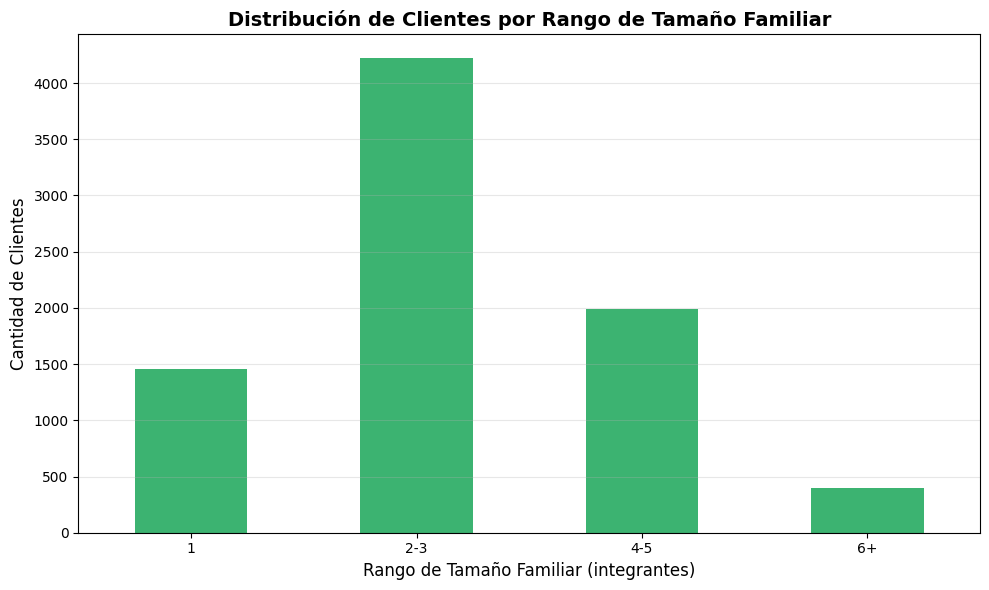

In [27]:
family_bins = [1, 2, 4, 6, 10]
family_labels = ['1', '2-3', '4-5', '6+']
dfFinal['Rango_Tamano_Familiar'] = pd.cut(dfFinal['Tamano_Familiar'], bins=family_bins, labels=family_labels, right=False)

family_range_counts = dfFinal['Rango_Tamano_Familiar'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
family_range_counts.plot(kind='bar', color='mediumseagreen')
plt.title('Distribución de Clientes por Rango de Tamaño Familiar', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Tamaño Familiar (integrantes)', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

###  ¿Cual es la distibución de edad por segmento? 

<Figure size 1200x600 with 0 Axes>

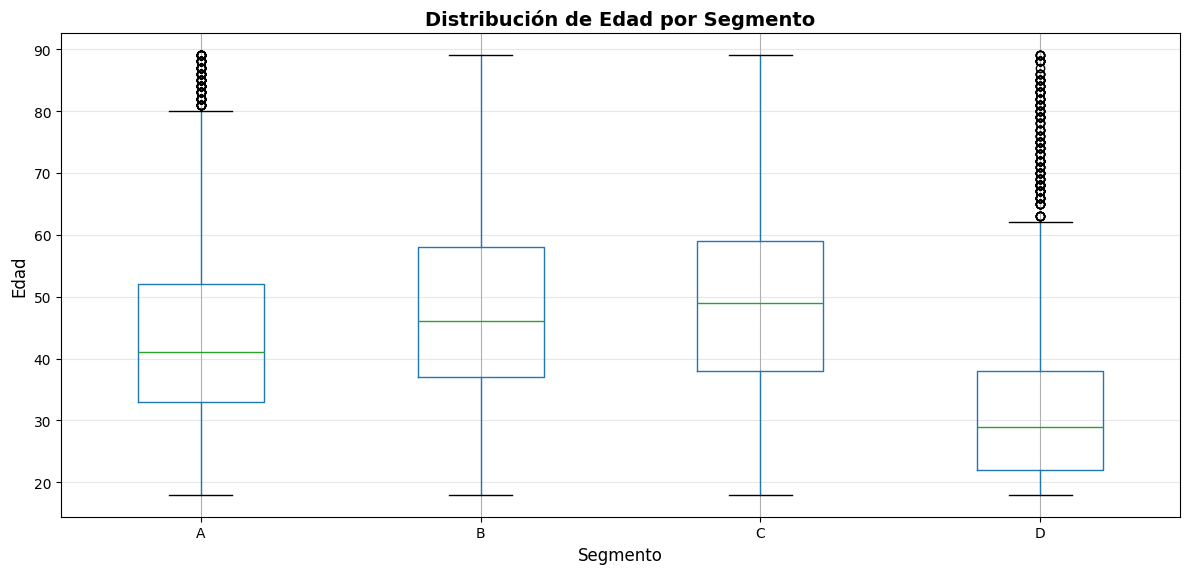

In [28]:
plt.figure(figsize=(12, 6))

# comparar la distribución de edad por segmento
dfFinal.boxplot(column='Edad', by='Segmento', figsize=(12, 6))
plt.title('Distribución de Edad por Segmento', fontsize=14, fontweight='bold')
plt.suptitle('') 
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Edad', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


* El Segmento D presenta una mediana de edad menor, lo que indica que está compuesto principalmente por clientes jóvenes.
* Los Segmentos B y C tienen las medianas más altas, lo que sugiere que concentran clientes de mayor edad.
* El Segmento A se encuentra en un punto intermedio.

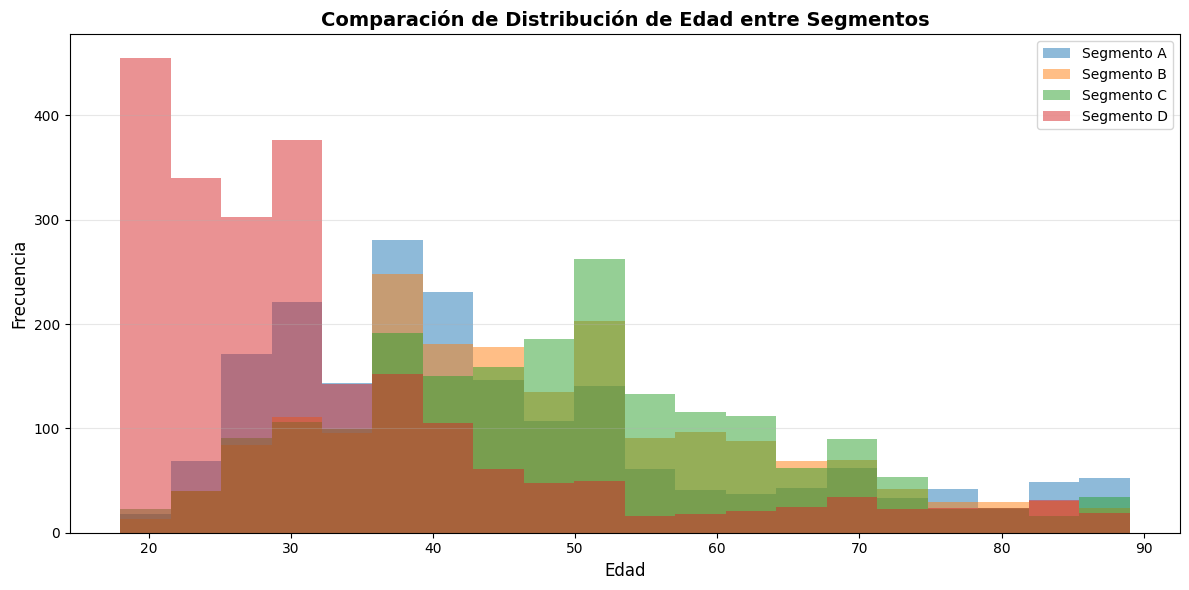

In [29]:
# Histograma agrupado por segmento
plt.figure(figsize=(12, 6))
for segment in ['A', 'B', 'C', 'D']:
    plt.hist(dfFinal[dfFinal['Segmento'] == segment]['Edad'], alpha=0.5, label=f'Segmento {segment}', bins=20)
plt.title('Comparación de Distribución de Edad entre Segmentos', fontsize=14, fontweight='bold')
plt.xlabel('Edad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El análisis de la distribución de edad revela que la variable edad es relevante para distinguir ciertos segmentos, particularmente el Segmento D, que agrupa clientes más jóvenes. 

Sin embargo, existe una superposición significativa entre los segmentos A, B y C, lo que indica que la segmentación no depende únicamente de la edad, sino de una combinación de múltiples variables.

### ¿Qué segmentos tienen mayor Spending Score (Puntuación de gasto)?

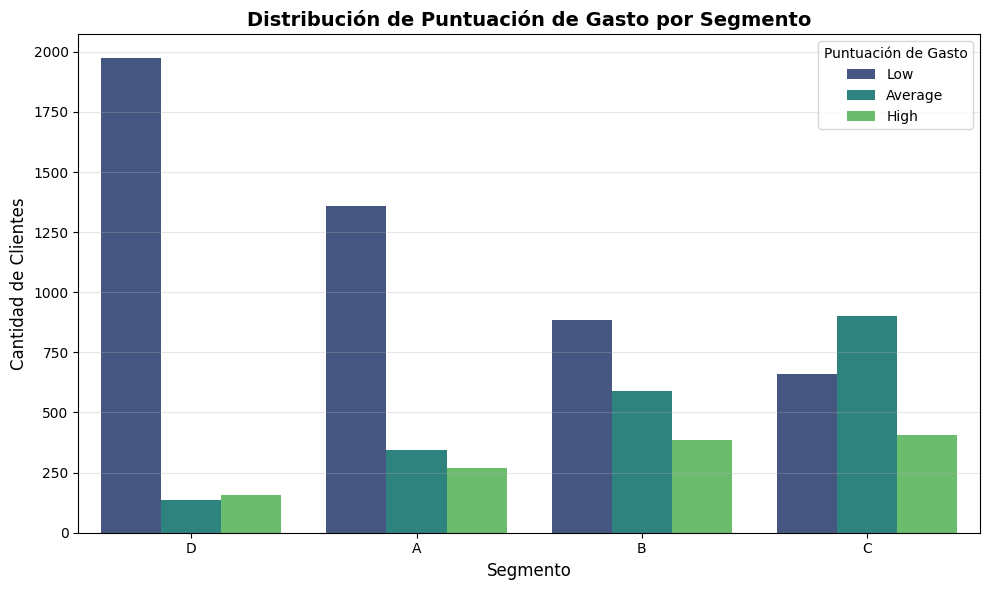

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=dfFinal, x='Segmento', hue='Puntuacion_Gasto', palette='viridis')
plt.title('Distribución de Puntuación de Gasto por Segmento', fontsize=14, fontweight='bold')
plt.xlabel('Segmento', fontsize=12)
plt.ylabel('Cantidad de Clientes', fontsize=12)
plt.legend(title='Puntuación de Gasto')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico muestra la cantidad de clientes en cada segmento según su nivel de gasto: bajo (Low), medio (Average) y alto (High).

* El Segmento D concentra la mayor cantidad de clientes con bajo nivel de gasto, y muy pocos con gasto medio o alto.
* El Segmento A también tiene predominancia de gasto bajo, aunque presenta más clientes con gasto medio y alto que el segmento D.
* El Segmento B muestra una distribución más equilibrada entre gasto bajo, medio y alto.
* El Segmento C destaca por tener la mayor cantidad de clientes con gasto medio y alto.

### ¿Cómo se distribuyen las profesiones dentro de cada segmento de clientes?


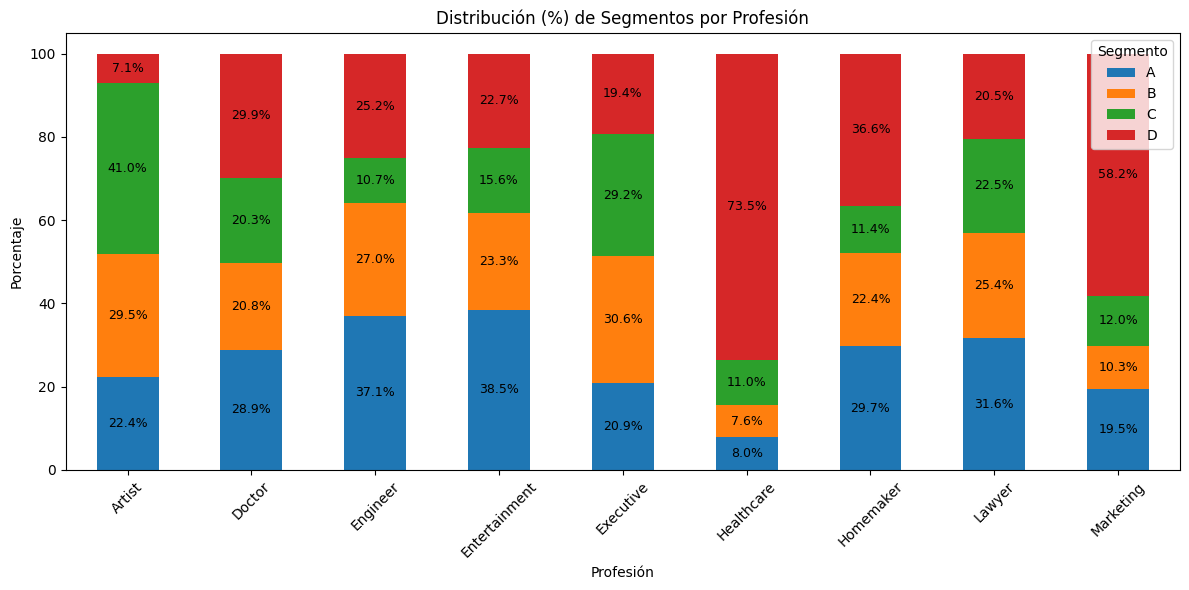

In [31]:
ct_pct = pd.crosstab(dfFinal['Profesion'], dfFinal['Segmento'], normalize='index') * 100

ax = ct_pct.plot(kind='bar', stacked=True, figsize=(12,6))

plt.title('Distribución (%) de Segmentos por Profesión')
plt.xlabel('Profesión')
plt.ylabel('Porcentaje')
plt.legend(title='Segmento')
plt.xticks(rotation=45)

# Agregar etiquetas de porcentaje
for i, row in enumerate(ct_pct.values):
    acumulado = 0
    for j, valor in enumerate(row):
        if valor > 3:  # solo mostrar si es visible
            ax.text(
                i, 
                acumulado + valor / 2, 
                f'{valor:.1f}%', 
                ha='center', 
                va='center', 
                fontsize=9,
                color='black'
            )
        acumulado += valor

plt.tight_layout()
plt.show()

### ¿Cómo varía la segmentación de clientes en función del nivel educativo?

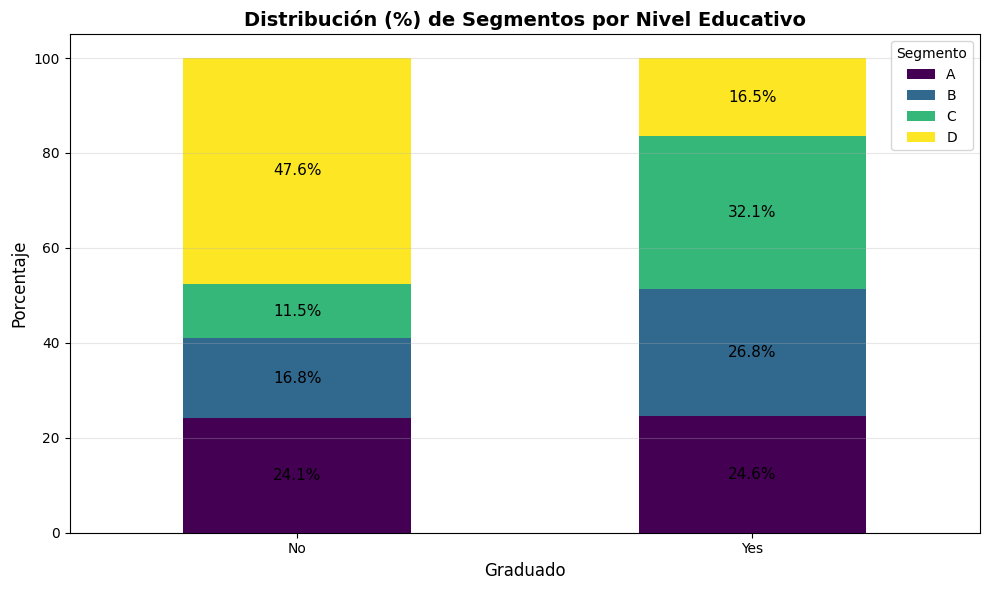

In [32]:
# Analizar la influencia del nivel educativo en la segmentación
ct_edu = pd.crosstab(dfFinal['Graduado'], dfFinal['Segmento'], normalize='index') * 100

ax = ct_edu.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')

plt.title('Distribución (%) de Segmentos por Nivel Educativo', fontsize=14, fontweight='bold')
plt.xlabel('Graduado', fontsize=12)
plt.ylabel('Porcentaje', fontsize=12)
plt.legend(title='Segmento')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

for i, row in enumerate(ct_edu.values):
    acumulado = 0
    for j, valor in enumerate(row):
        if valor > 3: 
            ax.text(
                i,
                acumulado + valor / 2,
                f'{valor:.1f}%',
                ha='center',
                va='center',
                fontsize=11,
                color='black'
            )
        acumulado += valor

plt.tight_layout()
plt.show()

### Heatmap de variables numericas

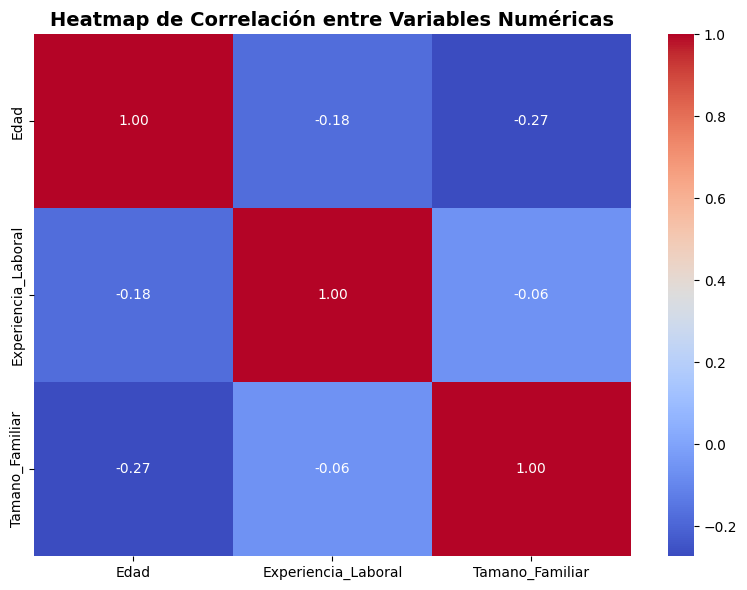

In [33]:
# Crear un heatmap de correlación para las variables numéricas
numerical_cols = ['Edad', 'Experiencia_Laboral', 'Tamano_Familiar']
corr = dfFinal[numerical_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap de Correlación entre Variables Numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

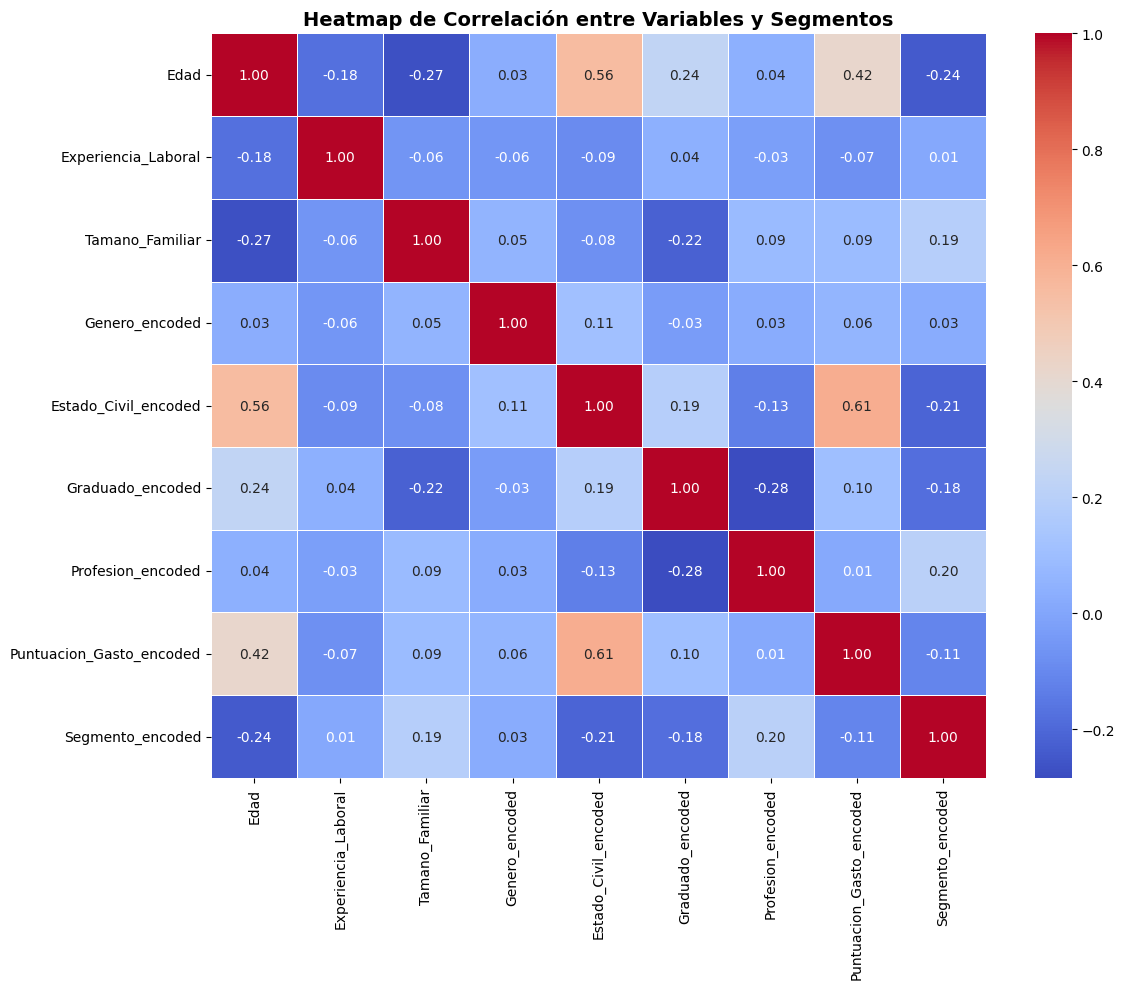

In [34]:
# Codificar variables categóricas a numéricas para el análisis de correlación
dfFinal['Genero_encoded'] = dfFinal['Genero'].map({'Male': 1, 'Female': 0})
dfFinal['Estado_Civil_encoded'] = dfFinal['Estado_Civil'].map({'Yes': 1, 'No': 0})
dfFinal['Graduado_encoded'] = dfFinal['Graduado'].map({'Yes': 1, 'No': 0})
dfFinal['Puntuacion_Gasto_encoded'] = dfFinal['Puntuacion_Gasto'].map({'Low': 1, 'Average': 2, 'High': 3})

le = LabelEncoder()
dfFinal['Profesion_encoded'] = le.fit_transform(dfFinal['Profesion'])

# Codificar el segmento a numérico
dfFinal['Segmento_encoded'] = dfFinal['Segmento'].map({'A': 1, 'B': 2, 'C': 3, 'D': 4})

# Seleccionar variables para la correlación
numerical_cols = ['Edad', 'Experiencia_Laboral', 'Tamano_Familiar']
encoded_cols = ['Genero_encoded', 'Estado_Civil_encoded', 'Graduado_encoded', 'Profesion_encoded', 'Puntuacion_Gasto_encoded', 'Segmento_encoded']
all_vars = numerical_cols + encoded_cols

# Calcular la matriz de correlación
corr = dfFinal[all_vars].corr()

# Crear el heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap de Correlación entre Variables y Segmentos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

...